## Problem Statement

Financial institutions need to determine whether a customer is likely to repay a loan or default. Incorrect decisions can lead to significant financial losses, especially when high-risk customers are approved for credit.

This project aims to build a machine learning model that classifies customers into low-risk or high-risk categories using features such as age, financial status, and loan details. A key challenge is the imbalanced dataset, where risky customers are fewer but more critical to identify.

The model is designed to maximize the detection of high-risk customers (recall) while maintaining good overall performance, using metrics like precision and ROC-AUC to support better lending decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import PowerTransformer
import category_encoders as ce
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from xgboost import XGBClassifier

In [2]:
credit_df = pd.read_csv(r"C:\Users\Chijioke\Downloads\german_credit_data (1).csv")

In [3]:
credit_df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# Drop the 'Unnamed: 0' column from the dataframe
credit_df = credit_df.drop(columns=['Unnamed: 0'])

# Basic Exploration

In [5]:
# Show dataset information (data types, non-null counts)
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [6]:
# Show statistical summary of numerical columns
credit_df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


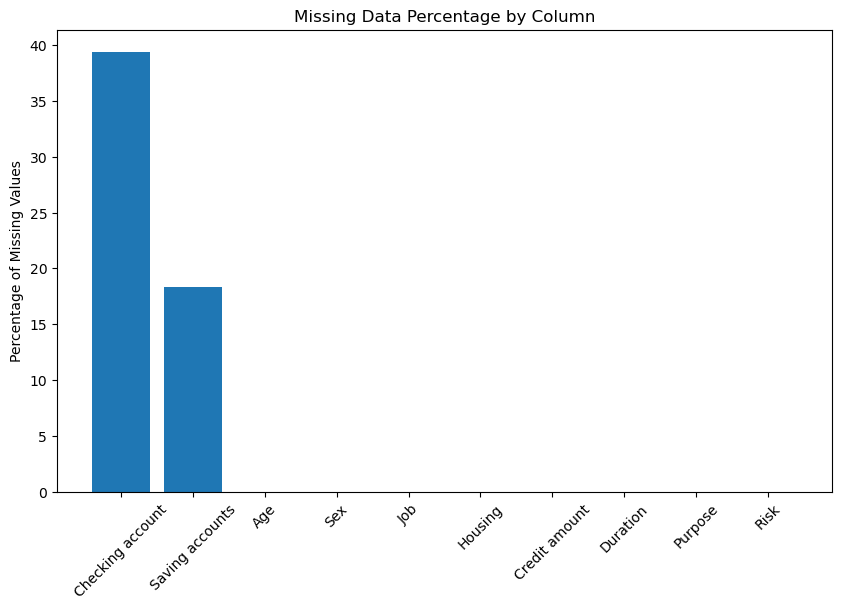

In [7]:
# Calculate missing percentage
missing_percentage = (credit_df.isnull().sum() / len(credit_df)) * 100

missing_percentage = missing_percentage.sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(missing_percentage.index, missing_percentage)

plt.xticks(rotation=45)

plt.ylabel("Percentage of Missing Values")
plt.title("Missing Data Percentage by Column")

plt.show()

# TARGET DISTRIBUTION

In [8]:
# Count how many good and bad credit cases we have
credit_df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

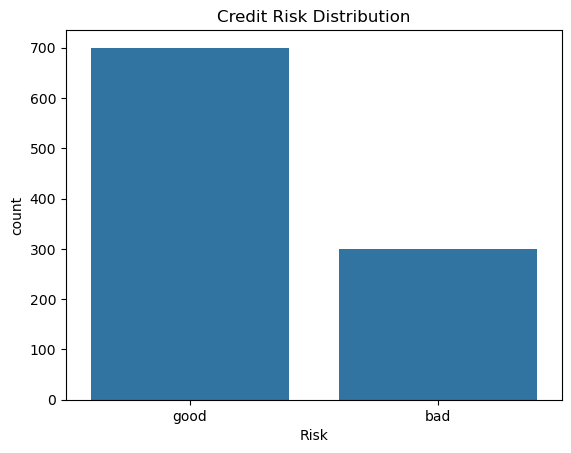

In [9]:
# Create a count plot to visualize class distribution
sns.countplot(x='Risk', data=credit_df)

plt.title("Credit Risk Distribution")

plt.show()

# EXPLORATORY DATA ANALYSIS

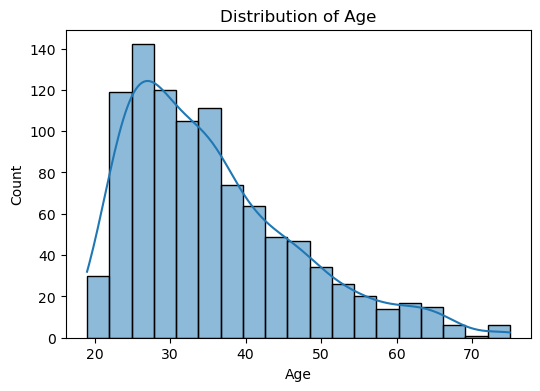

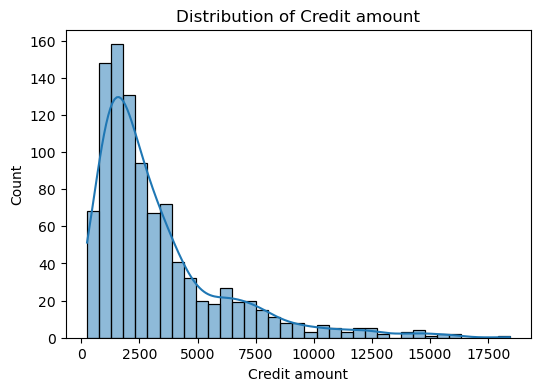

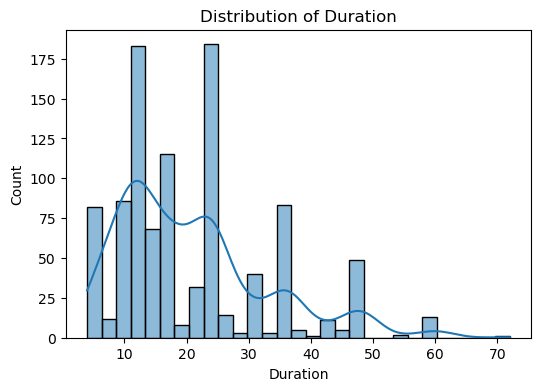

In [10]:
numerical_cols = ['Age', 'Credit amount', 'Duration']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(credit_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

👤 Distribution of Age

Most borrowers are between 25–40 years old, representing the working-age population.

Business Insight:
Younger borrowers may have less financial stability, while middle-aged customers likely have more stable income. Age may influence repayment behavior and credit risk.


💰 Distribution of Credit Amount

Most customers borrow between 1,000–4,000 DM, with a few very large loans (right-skewed distribution).

Business Insight:
Higher loan amounts increase the bank’s financial exposure. Large loans may carry higher default risk, especially when combined with long repayment periods.


📊 Distribution of Duration (Loan Term)

Most loans are between 12–24 months, with fewer long-term loans (above 36 months).

Business Insight:
The bank mainly offers short- to medium-term loans. Longer loan durations increase uncertainty and may raise default risk because borrowers are exposed to financial changes over time.

📌 Overall Insight

Loan duration, credit amount, and age appear to be important factors in assessing credit risk. These variables will likely play a key role in predicting whether a customer is safe or risky.

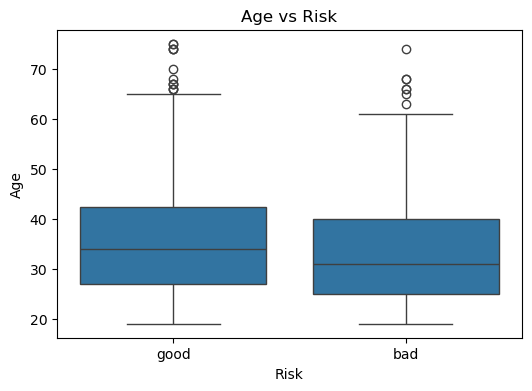

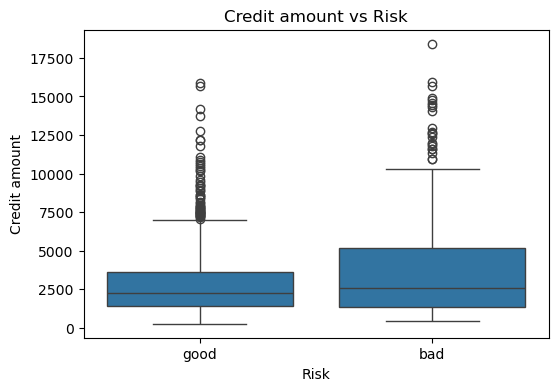

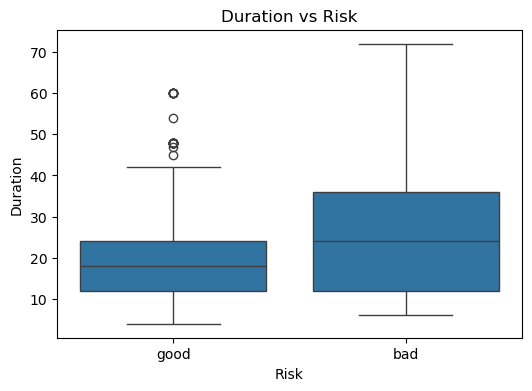

In [11]:
# Create boxplots to compare the distribution of each numerical feature across credit risk categories
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Risk', y=col, data=credit_df)
    plt.title(f"{col} vs Risk")
    plt.show()

👤 Age vs Risk

Risky customers are slightly younger on average than safe customers.

Business Insight:
Younger borrowers may have less financial stability or shorter credit history, increasing default risk.

💰 Credit Amount vs Risk

Risky customers generally take higher credit amounts, and the variability is larger.

Business Insight:
Higher loan amounts increase the bank’s exposure and potential loss if the borrower defaults.

📊 Duration vs Risk

Risky customers (“bad”) tend to have longer loan durations compared to safe customers.

Business Insight:
Longer repayment periods increase financial uncertainty and may raise the likelihood of default.

📌 Overall Conclusion

Longer loan duration, higher credit amount, and younger age are associated with increased credit risk and should be important predictors in the risk model.

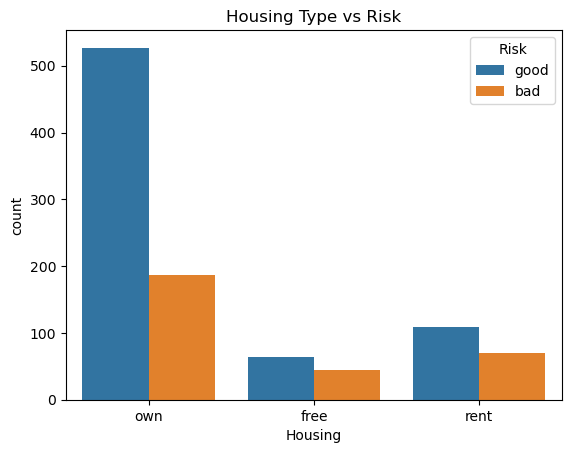

In [12]:
# Generate a percentage cross-tabulation of Housing vs Risk and visualize their distribution using a count plot.

pd.crosstab(credit_df['Housing'], credit_df['Risk'], normalize='index') * 100

sns.countplot(x='Housing', hue='Risk', data=credit_df)
plt.title("Housing Type vs Risk")
plt.show()

Most customers who own their homes fall into the good risk category, showing a strong repayment profile. Customers who rent or live free have a relatively higher proportion of bad risk cases compared to homeowners.

Business insight: Homeownership is associated with lower credit risk, so housing status can be a useful factor in risk assessment and lending decisions.

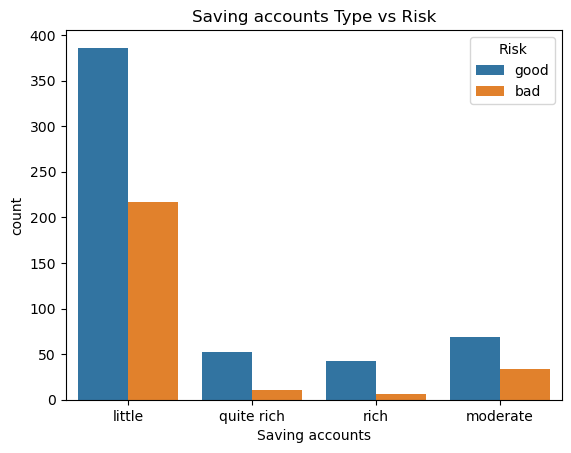

In [13]:
# Create a percentage cross-tab of Saving Accounts vs Risk and visualize their distribution using a count plot.
pd.crosstab(credit_df['Saving accounts'], credit_df['Risk'], normalize='index') * 100 

sns.countplot(x='Saving accounts', hue='Risk', data=credit_df) 
plt.title("Saving accounts Type vs Risk") 
plt.show()

Customers with little savings show a higher number of bad risk cases compared to those with moderate or rich savings. As savings increase, the proportion of good risk customers also improves.

Business insight: Stronger savings levels are linked to lower credit risk, making savings account balance an important factor in credit evaluation.

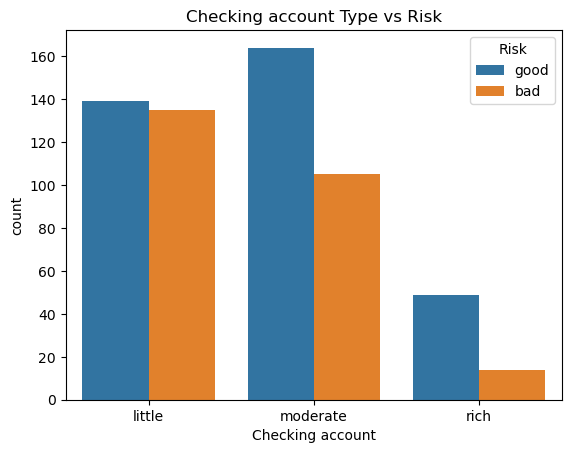

In [14]:
pd.crosstab(credit_df['Checking account'], credit_df['Risk'], normalize='index') * 100

sns.countplot(x='Checking account', hue='Risk', data=credit_df) 
plt.title("Checking account Type vs Risk") 
plt.show()

Customers with little checking account balances show a nearly equal number of good and bad risk cases, indicating higher credit risk. As checking account balance increases (moderate to rich), the proportion of good risk customers becomes significantly higher.

Business insight: Higher checking account balances are associated with lower default risk, making checking account status a strong indicator for credit approval decisions.

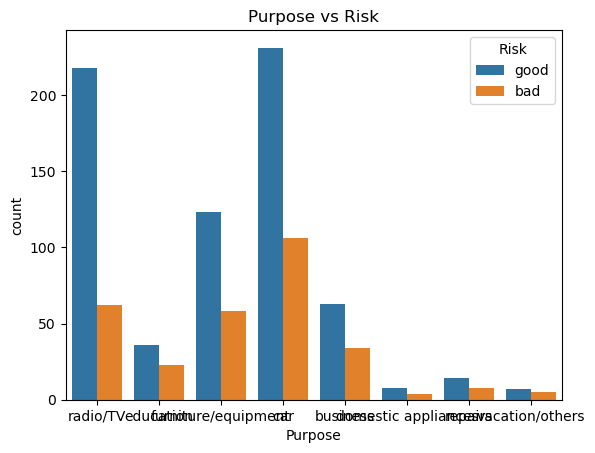

In [15]:
pd.crosstab(credit_df['Purpose'], credit_df['Risk'], normalize='index') * 100

sns.countplot(x='Purpose', hue='Risk', data=credit_df) 
plt.title("Purpose vs Risk") 
plt.show()

Most loan purposes (especially car, radio/TV, and furniture/equipment) have a higher number of good risk customers compared to bad risk. However, categories like business and education show a relatively higher proportion of bad risk cases.

Business insight: Loan purpose influences repayment behavior, so higher-risk purposes may require stricter credit assessment or additional guarantees.

In [16]:
# Create age groups from the Age column and calculate the percentage distribution of Risk within each age group.
credit_df['Age Group'] = pd.cut(credit_df['Age'], bins=[18,25,35,50,65,100])

pd.crosstab(credit_df['Age Group'], credit_df['Risk'], normalize='index') * 100

Risk,bad,good
Age Group,,
"(18, 25]",42.105263,57.894737
"(25, 35]",29.648241,70.351759
"(35, 50]",23.745819,76.254181
"(50, 65]",27.368421,72.631579
"(65, 100]",27.777778,72.222222


Younger customers (18–25) have the highest proportion of bad risk cases, while customers aged 35–50 show the lowest default rate and strongest good risk profile.

Business insight: Credit risk decreases with age up to middle age, so younger borrowers may require stricter screening or lower credit limits.

### Loan Intensity Feature

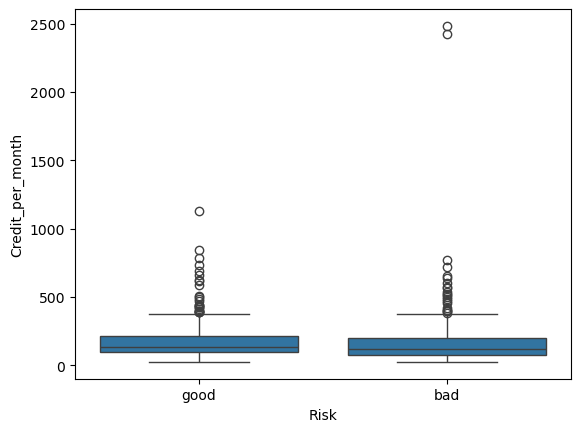

In [17]:
# Create a new feature that calculates the monthly credit amount by dividing total credit amount by loan duration.

credit_df['Credit_per_month'] = credit_df['Credit amount'] / credit_df['Duration']

sns.boxplot(x='Risk', y='Credit_per_month', data=credit_df)
plt.show()

Customers in the bad risk category tend to have slightly higher monthly credit amounts and more extreme high outliers compared to good risk customers.

Business insight: Higher monthly repayment burdens may increase default risk, so loans with large monthly installments should be assessed more carefully.

## Correlation Analysis

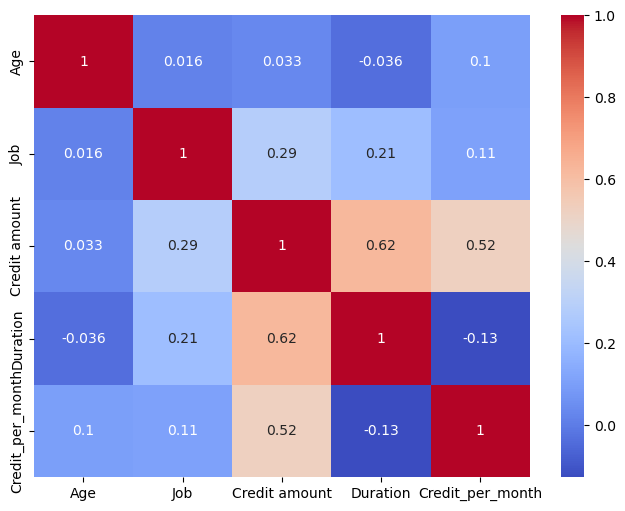

In [18]:
# Plot a heatmap to visualize the correlation between all numerical variables in the dataset.
plt.figure(figsize=(8,6))
sns.heatmap(credit_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

The strongest relationship is between Credit Amount and Duration (0.62) and Credit Amount and Credit per Month (0.52), meaning larger loans are usually taken for longer periods and result in higher monthly payments.

Business insight: Loan size is a key driver of repayment structure, while age and job show weak correlations, suggesting they have less direct impact on loan amount or duration.

## Missing Values Insight

In [19]:
# Calculate percentage of missing (null) values in each column
null_percentage = (credit_df.isnull().sum() / len(credit_df)) * 100

# Display the result sorted from highest to lowest
null_percentage.sort_values(ascending=False)

Checking account    39.4
Saving accounts     18.3
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
Age Group            0.0
Credit_per_month     0.0
dtype: float64

In [20]:
credit_df['Checking account'] = credit_df['Checking account'].fillna('No Account')
credit_df['Saving accounts'] = credit_df['Saving accounts'].fillna('No Account')

In [21]:
credit_df['Checking account'].unique()

array(['little', 'moderate', 'No Account', 'rich'], dtype=object)

In [22]:
credit_df['Saving accounts'].unique()

array(['No Account', 'little', 'quite rich', 'rich', 'moderate'],
      dtype=object)

In [23]:
credit_df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
Age Group           0
Credit_per_month    0
dtype: int64

# FEATURES ENGINEERING

In [24]:
# Create a new feature that calculates the monthly repayment burden by dividing credit amount by loan duration.
credit_df['Monthly_Burden'] = credit_df['Credit amount'] / credit_df['Duration']

In [25]:
# Create a feature that measures repayment burden relative to age by dividing monthly burden by age.
credit_df['Burden_Age_Ratio'] = credit_df['Monthly_Burden'] / credit_df['Age']

In [26]:
# Create a new column by applying log transformation to Credit amount to reduce skewness
credit_df['Log_Credit_Amount'] = np.log1p(credit_df['Credit amount'])

In [27]:
saving_map = {
    'No Account': 0,
    'little': 1,
    'moderate': 2,
    'quite rich': 3,
    'rich': 4
}

credit_df['Saving_Score'] = credit_df['Saving accounts'].map(saving_map)

In [28]:
checking_map = {
    'No Account': 0,
    'little': 1,
    'moderate': 2,
    'rich': 3
}

credit_df['Checking_Score'] = credit_df['Checking account'].map(checking_map)

In [29]:
# Create a Liquidity Score by combining Saving_Score and Checking_Score to represent overall financial strength.
credit_df['Liquidity_Score'] = (
    credit_df['Saving_Score'] + credit_df['Checking_Score']
)

In [30]:
# Create a Credit Intensity feature by calculating the monthly credit amount (credit amount divided by duration).
credit_df['Credit_Intensity'] = (
    credit_df['Credit amount'] / credit_df['Duration']
)

In [31]:
# Create a binary feature indicating whether the loan duration is long-term (greater than 36 months).
credit_df['Long_Term_Loan'] = (credit_df['Duration'] > 36).astype(int)

In [32]:
# Segment customers into numeric age groups based on age ranges for use in modeling.
credit_df['Age_Group'] = pd.cut(
    credit_df['Age'],
    bins=[18, 25, 35, 50, 100],
    labels=[0, 1, 2, 3]  # numeric for modeling
)

In [33]:
# Create a binary flag indicating low-skill employment based on job category.
credit_df['Low_Skill_Flag'] = (credit_df['Job'] <= 1).astype(int)

In [34]:
# Create a feature comparing financial liquidity to repayment burden, with +1 added to avoid division by zero.
credit_df['Liquidity_vs_Burden'] = (
    credit_df['Liquidity_Score'] / (credit_df['Monthly_Burden'] + 1)
)

In [35]:
# Encode the Risk variable as binary values for modeling (good = 0, bad = 1).
credit_df['Risk'] = credit_df['Risk'].map({'good': 0, 'bad': 1})

## Correlation Analysis

In [36]:
numerical_columns1 = credit_df.select_dtypes(include=['int', 'float']).columns

In [37]:
# Calculate the correlation matrix for numerical columns
correlation_matrix1= credit_df[numerical_columns1].corr()

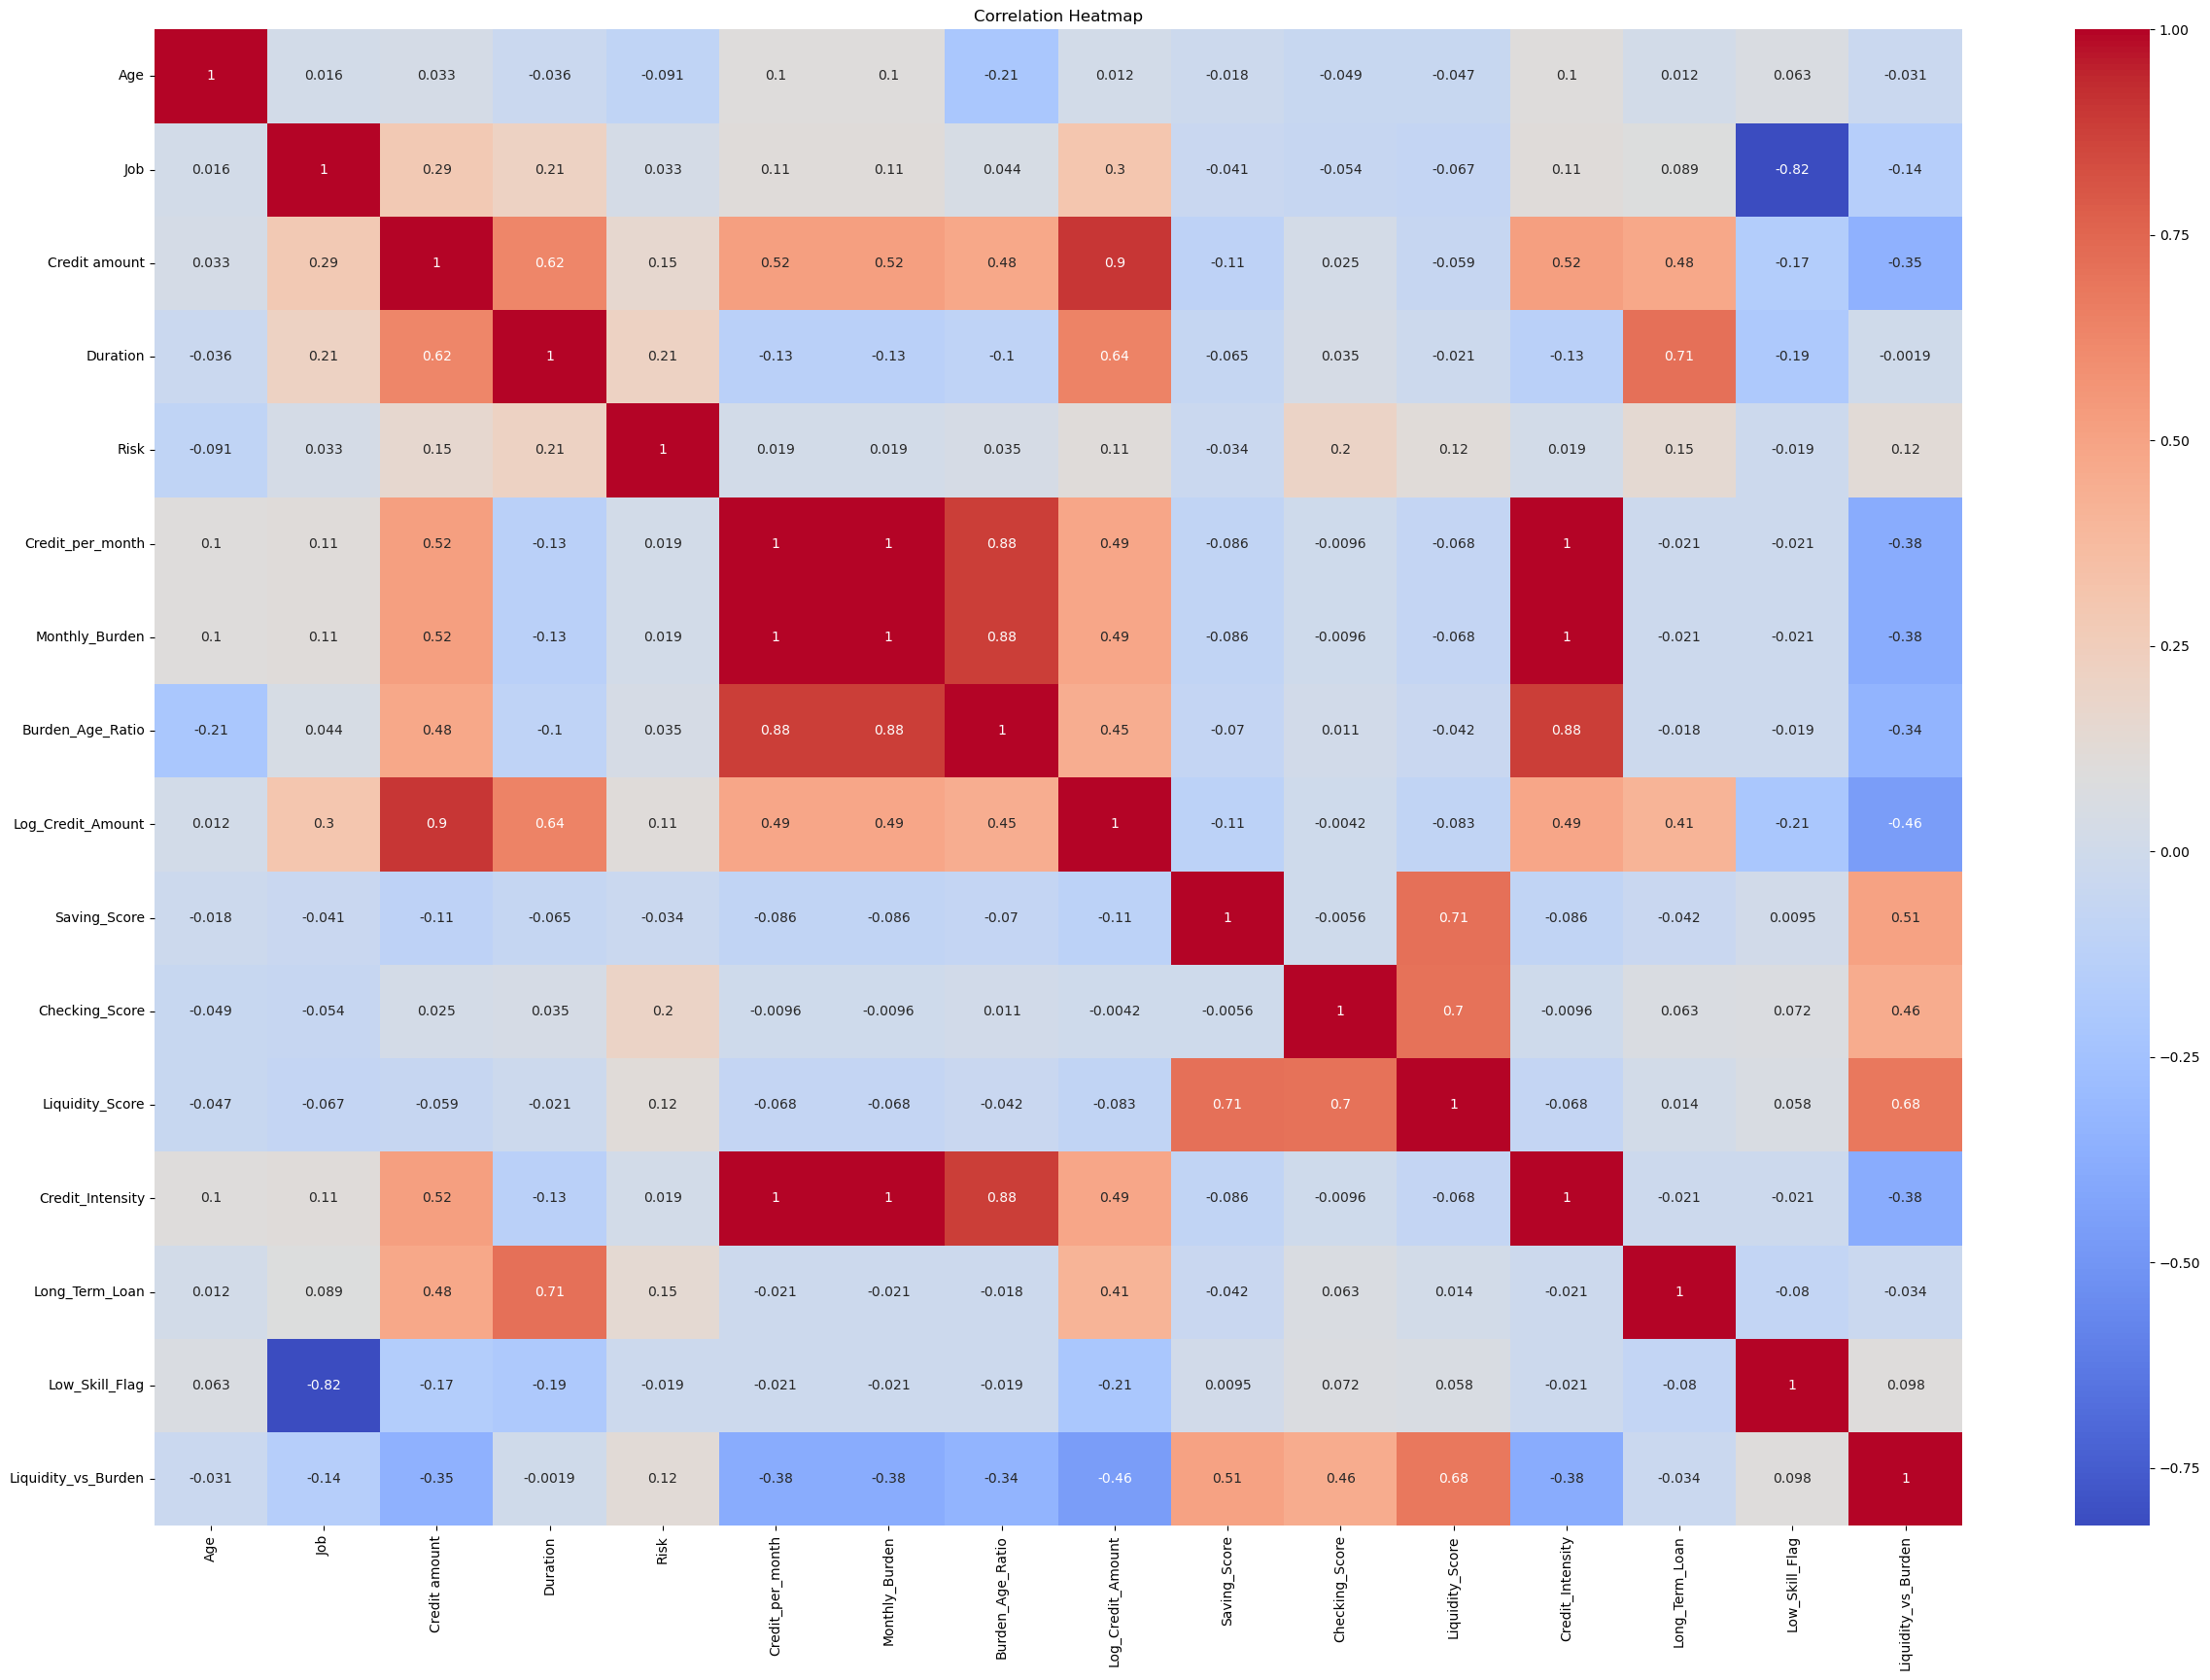

In [38]:
# Plot the heatmap
# Set the figure size (width and height in inches)
plt.figure(figsize=(30, 20))
sns.heatmap(correlation_matrix1, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

## checking the correlation with categorical columns

In [39]:
# List of categorical columns you want to analyze
categorical_columns = ['Sex','Housing','Saving accounts','Checking account','Purpose','Age Group','Age_Group']  
# Add your columns here

In [40]:
# ANOVA: Analyzing the relationship between categorical columns and the target variable
for col in categorical_columns:
    # Group the data by categorical column and get the values of the target variable for each group
    groups = [group['Risk'] for name, group in credit_df.groupby(col, observed=True)]
    
    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*groups)
    
    print(f"ANOVA results for {col}:")
    print(f"F-statistic: {f_stat}, p-value: {p_val}\n")

ANOVA results for Sex:
F-statistic: 5.720350177999688, p-value: 0.016953676392245272

ANOVA results for Housing:
F-statistic: 9.240802164395783, p-value: 0.00010556361953257901

ANOVA results for Saving accounts:
F-statistic: 9.315902482632273, p-value: 2.157599468053148e-07

ANOVA results for Checking account:
F-statistic: 46.874740350664325, p-value: 2.435562586820884e-28

ANOVA results for Purpose:
F-statistic: 1.9600172395488749, p-value: 0.05756219982245603

ANOVA results for Age Group:
F-statistic: 4.871150822570944, p-value: 0.0006812902326863829

ANOVA results for Age_Group:
F-statistic: 6.500978510147696, p-value: 0.0002342899734429627



## dropping features that are strongly correlated

In [41]:
credit_df.drop(
    [
        'Credit amount',
        'Credit_per_month',
        'Monthly_Burden',
        'Credit_Intensity',
        'Burden_Age_Ratio',
        'Saving_Score',
        'Checking_Score',
        'Job',
        'Age Group'
    ],
    axis=1,
    inplace=True
)

Highly correlated engineered features were pruned using correlation analysis and ANOVA testing to reduce multicollinearity, improve model stability, and retain only economically meaningful predictors.

In [42]:
credit_df.columns

Index(['Age', 'Sex', 'Housing', 'Saving accounts', 'Checking account',
       'Duration', 'Purpose', 'Risk', 'Log_Credit_Amount', 'Liquidity_Score',
       'Long_Term_Loan', 'Age_Group', 'Low_Skill_Flag', 'Liquidity_vs_Burden'],
      dtype='object')

## CHECKING FOR OUTLIERS

In [43]:
credit_df.describe()

,Age,Duration,Risk,Log_Credit_Amount,Liquidity_Score,Long_Term_Loan,Low_Skill_Flag,Liquidity_vs_Burden
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,20.903000,0.300000,7.789244,2.191000,0.087000,0.222000,0.019494
std,11.375469,12.058814,0.458487,0.776074,1.356598,0.281976,0.415799,0.018825
min,19.000000,4.000000,0.000000,5.525453,0.000000,0.000000,0.000000,0.000000
25%,27.000000,12.000000,0.000000,7.220008,1.000000,0.000000,0.000000,0.007276
50%,33.000000,18.000000,0.000000,7.749538,2.000000,0.000000,0.000000,0.014504
75%,42.000000,24.000000,1.000000,8.287340,3.000000,0.000000,0.000000,0.026850
max,75.000000,72.000000,1.000000,9.821464,7.000000,1.000000,1.000000,0.199525


In [44]:
lower_percentile = 0.01  # 1st percentile
upper_percentile = 0.99  # 99th percentile

In [45]:
# Calculate the 1st and 99th percentiles for each numeric column
percentiles = credit_df.select_dtypes(include='number').quantile([lower_percentile, upper_percentile])

In [46]:
# Initialize a mask for outlier rows
outliers_mask = pd.Series(False, index=credit_df.index)

In [47]:
for column in credit_df.select_dtypes(include='number').columns:
    lower_bound = percentiles.loc[lower_percentile, column]
    upper_bound = percentiles.loc[upper_percentile, column]

In [48]:
# Update the mask with outliers in the current column
outliers_mask = outliers_mask | (
(credit_df[column] < lower_bound) | (credit_df[column] > upper_bound))

In [49]:
# Get the rows with outliers
outlier_rows = credit_df[outliers_mask]

print(f"Number of rows with outliers: {len(outlier_rows)}")
print(outlier_rows)

Number of rows with outliers: 10
     Age     Sex Housing Saving accounts Checking account  Duration  \
27    42  female    rent            rich             rich        12   
111   23  female    rent          little             rich        15   
164   36    male     own      quite rich       No Account        36   
309   22    male    rent          little         moderate         9   
648   38    male    free          little             rich        24   
702   47  female    free        moderate             rich        24   
725   41  female     own            rich       No Account         6   
729   36    male     own            rich             rich        24   
955   57  female    rent            rich           little        24   
975   57  female     own      quite rich             rich        24   

       Purpose  Risk  Log_Credit_Amount  Liquidity_Score  Long_Term_Loan  \
27    radio/TV     0           6.016157                7               0   
111  education     0           5.

## CAPPING OUTLIERS

In [50]:
lower_percentile = 0.01  # Lower bound (e.g., 1st percentile)
upper_percentile = 0.99  # Upper bound (e.g., 99th percentile)

# Separate numerical, datetime, and object columns
numerical_columns = credit_df.select_dtypes(include='number').columns.drop('Risk')


# Calculate the lower and upper bounds for each numerical column
lower_bounds = credit_df[numerical_columns].quantile(lower_percentile)
upper_bounds = credit_df[numerical_columns].quantile(upper_percentile)

# Function to cap outliers in each numerical column
def cap_outliers(col, lower, upper):
    return col.clip(lower=lower, upper=upper)

# Apply capping to numerical columns
credit_df[numerical_columns] = credit_df[numerical_columns].apply(lambda col: cap_outliers(col, lower_bounds[col.name], upper_bounds[col.name]))

In [51]:
def balance_skewness_credit_df(skew_threshold=1.0):
    """
    Reduce skewness in numerical features using Yeo-Johnson transformation.
    """

    global credit_df
    credit_df = credit_df.copy()

    # Select numerical columns (exclude target)
    numerical_columns = credit_df.select_dtypes(include='number').columns.drop('Risk')

    # Identify highly skewed columns
    skewed_cols = [
        col for col in numerical_columns
        if abs(credit_df[col].skew()) > skew_threshold
    ]

    # Apply Yeo-Johnson transformation
    if skewed_cols:
        pt = PowerTransformer(method='yeo-johnson')
        credit_df[skewed_cols] = pt.fit_transform(credit_df[skewed_cols])

    return credit_df

## Encoding The Categorical Columns

In [52]:
categorical_cols = credit_df.select_dtypes(include='object').columns
categorical_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [53]:
# encoding the categorical columns
categorical_cols = [
    'Sex',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose',
    'Age_Group'
]

encoder = ce.OneHotEncoder(
    cols=categorical_cols,
    use_cat_names=True
)

credit_df_encoded = encoder.fit_transform(credit_df)

In [54]:
encoder

,verbose,0
,cols,"['Sex', 'Housing', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [55]:
X = credit_df.drop('Risk', axis=1)
y = credit_df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [57]:
X_train_encoded.head(5)

,Age,Sex_male,Sex_female,Housing_free,Housing_own,Housing_rent,Saving accounts_No Account,Saving accounts_little,Saving accounts_moderate,Saving accounts_rich,...,Purpose_business,Log_Credit_Amount,Liquidity_Score,Long_Term_Loan,Age_Group_0.0,Age_Group_1.0,Age_Group_2.0,Age_Group_3.0,Low_Skill_Flag,Liquidity_vs_Burden
828,47.0,1,0,1,0,0,1,0,0,0,...,0,9.028339,1,0,0,0,1,0,0,0.004301
997,38.0,1,0,0,1,0,0,1,0,0,...,0,6.690842,1,0,0,0,1,0,0,0.014706
148,28.0,1,0,0,1,0,0,1,0,0,...,0,8.588956,2,0,0,1,0,0,0,0.013316
735,29.0,0,1,0,1,0,1,0,0,0,...,0,8.291797,2,0,0,1,0,0,1,0.017884
130,24.0,0,1,0,1,0,1,0,0,0,...,0,9.046409,2,1,1,0,0,0,0,0.011248


In [58]:
X_test_encoded.head()

,Age,Sex_male,Sex_female,Housing_free,Housing_own,Housing_rent,Saving accounts_No Account,Saving accounts_little,Saving accounts_moderate,Saving accounts_rich,...,Purpose_business,Log_Credit_Amount,Liquidity_Score,Long_Term_Loan,Age_Group_0.0,Age_Group_1.0,Age_Group_2.0,Age_Group_3.0,Low_Skill_Flag,Liquidity_vs_Burden
30,36.0,1,0,0,1,0,0,0,0,1,...,1,7.556951,6,0,0,0,1,0,0,0.055930
128,34.0,1,0,0,1,0,0,1,0,0,...,0,7.528869,3,0,0,1,0,0,0,0.019231
289,48.0,1,0,0,1,0,0,1,0,0,...,0,6.932448,2,0,0,0,1,0,0,0.045802
216,31.0,1,0,0,1,0,0,1,0,0,...,1,8.040769,2,0,0,1,0,0,0,0.011531
966,23.0,1,0,0,1,0,0,0,0,0,...,0,7.832411,5,0,1,0,0,0,1,0.053004


In [59]:
X_train_encoded.isnull().sum().sum()

np.int64(0)

In [60]:
X_test_encoded.isnull().sum().sum()

np.int64(0)

In [61]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 828 to 749
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          800 non-null    float64
 1   Sex_male                     800 non-null    int64  
 2   Sex_female                   800 non-null    int64  
 3   Housing_free                 800 non-null    int64  
 4   Housing_own                  800 non-null    int64  
 5   Housing_rent                 800 non-null    int64  
 6   Saving accounts_No Account   800 non-null    int64  
 7   Saving accounts_little       800 non-null    int64  
 8   Saving accounts_moderate     800 non-null    int64  
 9   Saving accounts_rich         800 non-null    int64  
 10  Saving accounts_quite rich   800 non-null    int64  
 11  Checking account_little      800 non-null    int64  
 12  Checking account_No Account  800 non-null    int64  
 13  Checking account_modera

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [63]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled, y_train
)

## Feature selection

In [64]:
selector = SelectKBest(score_func=f_classif, k=15)
X_train_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test_scaled)

# Logistic Regression

In [65]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_sel, y_train_bal)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [66]:
# Probabilities
y_prob = log_model.predict_proba(X_test_sel)[:, 1]

In [67]:
# Business threshold
threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

In [68]:
# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.87      0.54      0.67       140
           1       0.43      0.82      0.57        60

    accuracy                           0.62       200
   macro avg       0.65      0.68      0.62       200
weighted avg       0.74      0.62      0.64       200

ROC-AUC: 0.7861904761904761


# SVM

In [69]:
svm = SVC(
    kernel='rbf',
    C=5,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_sel, y_train_bal)

,C,5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [70]:
# Train SVM
svm.fit(X_train_sel, y_train_bal)

# Predict probabilities
y_prob_svm = svm.predict_proba(X_test_sel)[:, 1]

In [71]:
# Business-driven threshold
threshold = 0.35
y_pred_svm = (y_prob_svm >= threshold).astype(int)

In [72]:
# Evaluation
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

              precision    recall  f1-score   support

           0       0.88      0.69      0.77       140
           1       0.52      0.78      0.62        60

    accuracy                           0.71       200
   macro avg       0.70      0.73      0.70       200
weighted avg       0.77      0.71      0.73       200

ROC-AUC: 0.7505952380952382


# Random Forest

In [73]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sel, y_train_bal)

,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_prob_rf = rf_model.predict_proba(X_test_sel)[:, 1]

In [75]:
threshold = 0.35
y_pred_rf = (y_prob_rf >= threshold).astype(int)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.88      0.56      0.69       140
           1       0.45      0.82      0.58        60

    accuracy                           0.64       200
   macro avg       0.66      0.69      0.63       200
weighted avg       0.75      0.64      0.65       200

ROC-AUC: 0.7654761904761904


# KNN

In [76]:
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="minkowski",
    p=2  # Euclidean distance
)

knn.fit(X_train_sel, y_train_bal)

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [77]:
y_prob_knn = knn.predict_proba(X_test_sel)[:, 1]

In [78]:
threshold = 0.35
y_pred_knn = (y_prob_knn >= threshold).astype(int)

print(classification_report(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

              precision    recall  f1-score   support

           0       0.88      0.61      0.72       140
           1       0.47      0.80      0.59        60

    accuracy                           0.67       200
   macro avg       0.67      0.70      0.65       200
weighted avg       0.75      0.67      0.68       200

ROC-AUC: 0.7625


# XGBoost

In [79]:
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [80]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_sel, y_train_bal)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [81]:
y_prob = xgb_model.predict_proba(X_test_sel)[:, 1]

threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.57      0.68       140
           1       0.43      0.77      0.55        60

    accuracy                           0.63       200
   macro avg       0.64      0.67      0.62       200
weighted avg       0.73      0.63      0.64       200

ROC-AUC: 0.7419047619047618


## Evaluate all models

In [82]:
def evaluate_model(name, model, X_test, y_test, threshold=0.35):
    """
    Evaluates a classification model and returns key performance metrics.
    """
    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Risk=1)": precision_score(y_test, y_pred),
        "Recall (Risk=1)": recall_score(y_test, y_pred),
        "F1-score (Risk=1)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [83]:
results = []

results.append(evaluate_model(
    "Logistic Regression", log_model, X_test_sel, y_test
))

results.append(evaluate_model(
    "SVM", svm, X_test_sel, y_test
))

results.append(evaluate_model(
    "Random Forest", rf_model, X_test_sel, y_test
))

results.append(evaluate_model(
    "KNN", knn, X_test_sel, y_test
))

results.append(evaluate_model(
    "XGBoost", knn, X_test_sel, y_test
))

In [84]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.round(3)
comparison_df

,Model,Accuracy,Precision (Risk=1),Recall (Risk=1),F1-score (Risk=1),ROC-AUC
0,Logistic Regression,0.625,0.434,0.817,0.566,0.786
1,SVM,0.715,0.516,0.783,0.623,0.751
2,Random Forest,0.640,0.445,0.817,0.576,0.765
3,KNN,0.665,0.466,0.800,0.589,0.762
4,XGBoost,0.665,0.466,0.800,0.589,0.762


### ROC-AUC Comparison

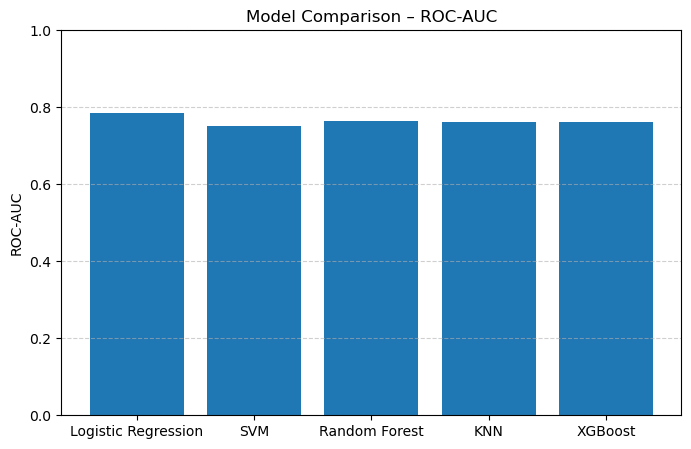

In [85]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"]
)
plt.title("Model Comparison – ROC-AUC")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Recall for Risky Customers

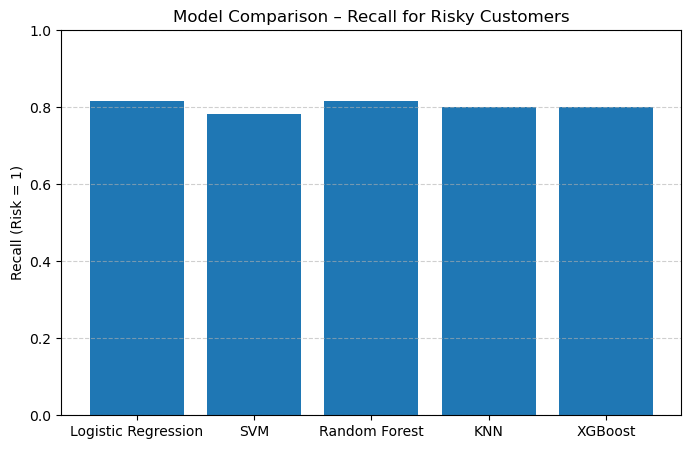

In [86]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Recall (Risk=1)"]
)
plt.title("Model Comparison – Recall for Risky Customers")
plt.ylabel("Recall (Risk = 1)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Professional conclusion

The models achieved strong performance, with Logistic Regression providing the best balance between recall and overall discrimination (ROC-AUC = 0.786). The system prioritizes identifying high-risk customers, which is critical in credit risk applications.